In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

# Wstępna eksploracja danych

In [7]:
df = pd.read_csv('C:/Users/User/Documents/MCHTR/DM/projekt/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


age - wiek

sex - płeć

cp - typ bólu w klatce piersiowej (od 0 do 3)

trestbps - Spoczynkowe ciśnienie krwi mmHg

chol - cholesterol w surowicy mg/dl

fbs - poziom glukozy na czczo większy niż 120 mg/dl (1 - tak, 0 - nie)

restecg - wynik kardiograficzny w spoczynku (od 0 do 2)

thalach - Maksymalne osiągalne tętno

exang - dławica wywołana wysiłkiem (1 - tak, 0 - nie)

oldpeak - depresja w odcinku ST wywołana wysiłkiem w porównaniu do spoczynku

slope - nachylenie szczytowego odcinka ST podczas ćwiczeń

ca - Liczba głównych naczyń krwionośnych pokolorowanych przy użyciu fluoroskopii (od 0 do 3)

thal - zaburzenia syntezy hemoglobiny (1 - norma, 2 - stała wada, 3 - wada odwracalna)

target - 0 - zdrowy, 1 - chory


In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Sprawdzenie kompletności danych.

Brak rekordów niekompletnych.

In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


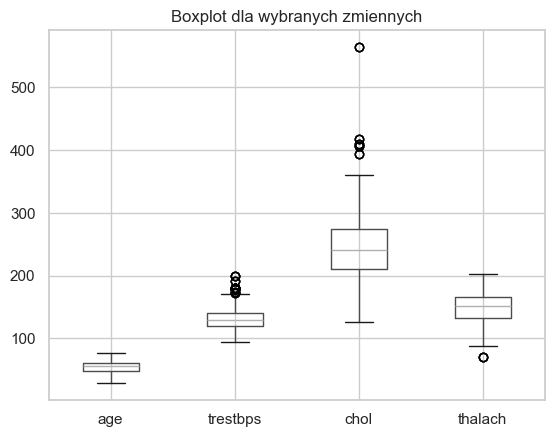

In [15]:
dfBP = df[["age","trestbps","chol","thalach"]]
dfBP.boxplot()
plt.title("Boxplot dla wybranych zmiennych")
plt.show()

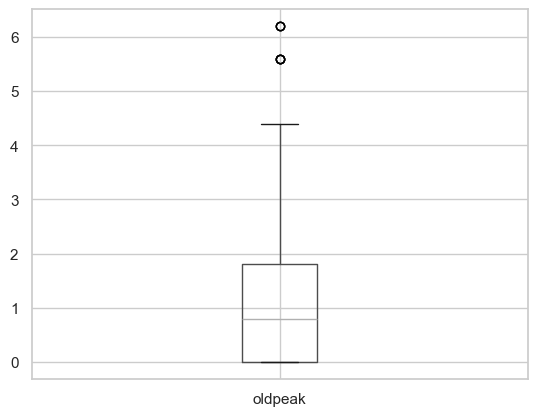

In [26]:
dfOP = df[["oldpeak"]]
dfOP.boxplot()
plt.show()

Przedstawiono wyłącznie boxploty z danymi numerycznymi (ciągłymi).

age - wiek

trestbps - Spoczynkowe ciśnienie krwi mmHg

chol - cholesterol w surowicy mg/dl

thalach - Maksymalne osiągalne tętno

oldpeak - depresja w odcinku ST wywołana wysiłkiem w porównaniu do spoczynku

Na wykresach nie zaobserwowano wartości odstających, dlatego zdecydowano się na pozostawienie wszystkich danych.


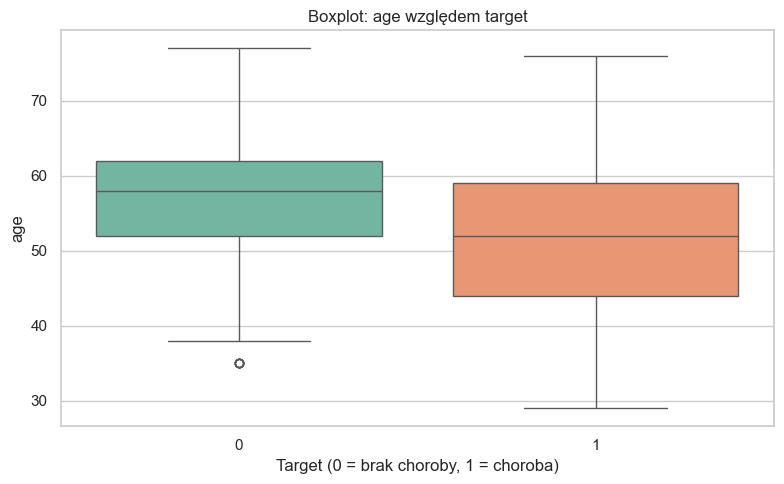

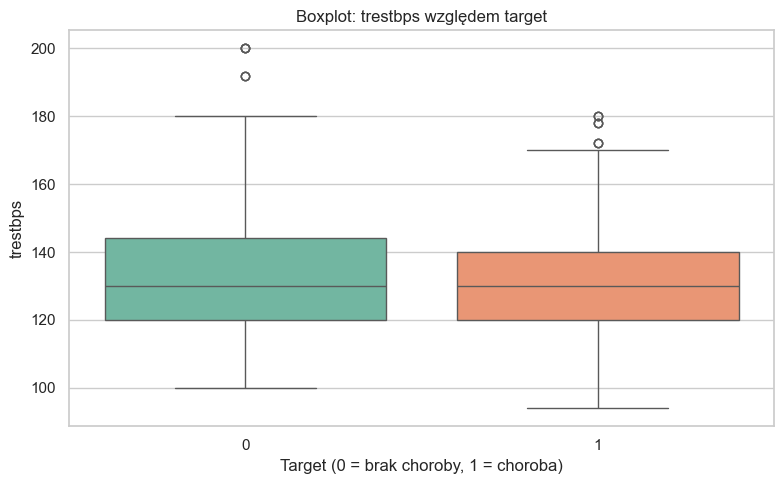

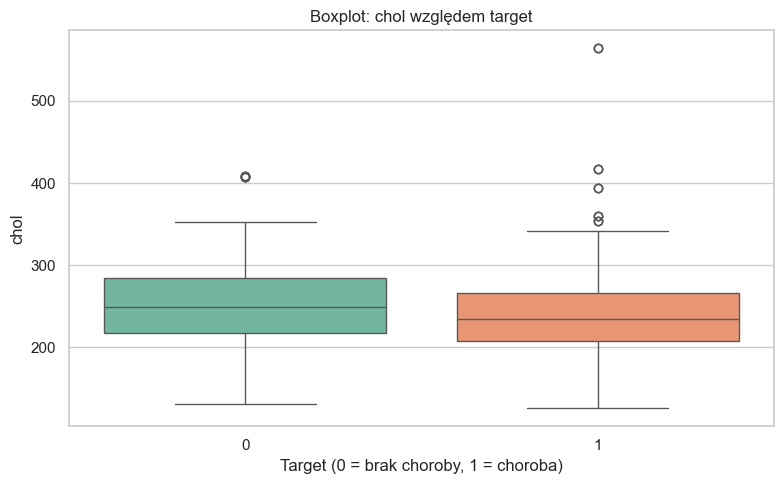

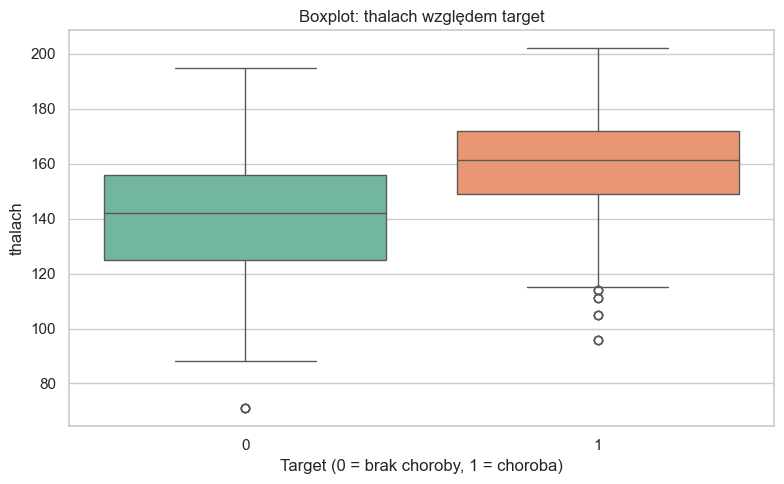

In [30]:
columns_to_plot = ["age", "trestbps", "chol", "thalach"]

for col in columns_to_plot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="target", y=col, hue="target", data=df, palette="Set2", dodge=False)
    plt.title(f'Boxplot: {col} względem target')
    plt.xlabel("Target (0 = brak choroby, 1 = choroba)")
    plt.ylabel(col)
    plt.legend([],[], frameon=False)  # Ukrycie legendy
    plt.tight_layout()
    plt.show()

Wygenerowano boxploty oddzielnie dla wartości parametru target 0 i 1

Dane wskazują na to, że ludzie starsi są częściej zdrowi niż młodsi.
Osoby z wyższym cholesterolem są częściej zdrowe niż te z niższym, także pacjenci z wyższym maksymalnym tętnem podczas wysiłku są częściej chore. Wydawało by się, że wyniki powinny być odwrotne co może wskazywać na specyficzność tego zbioru danych lub błąd przy ustaleniu wartości parametru target przez autora zbioru danych.

# Macierz korelacji

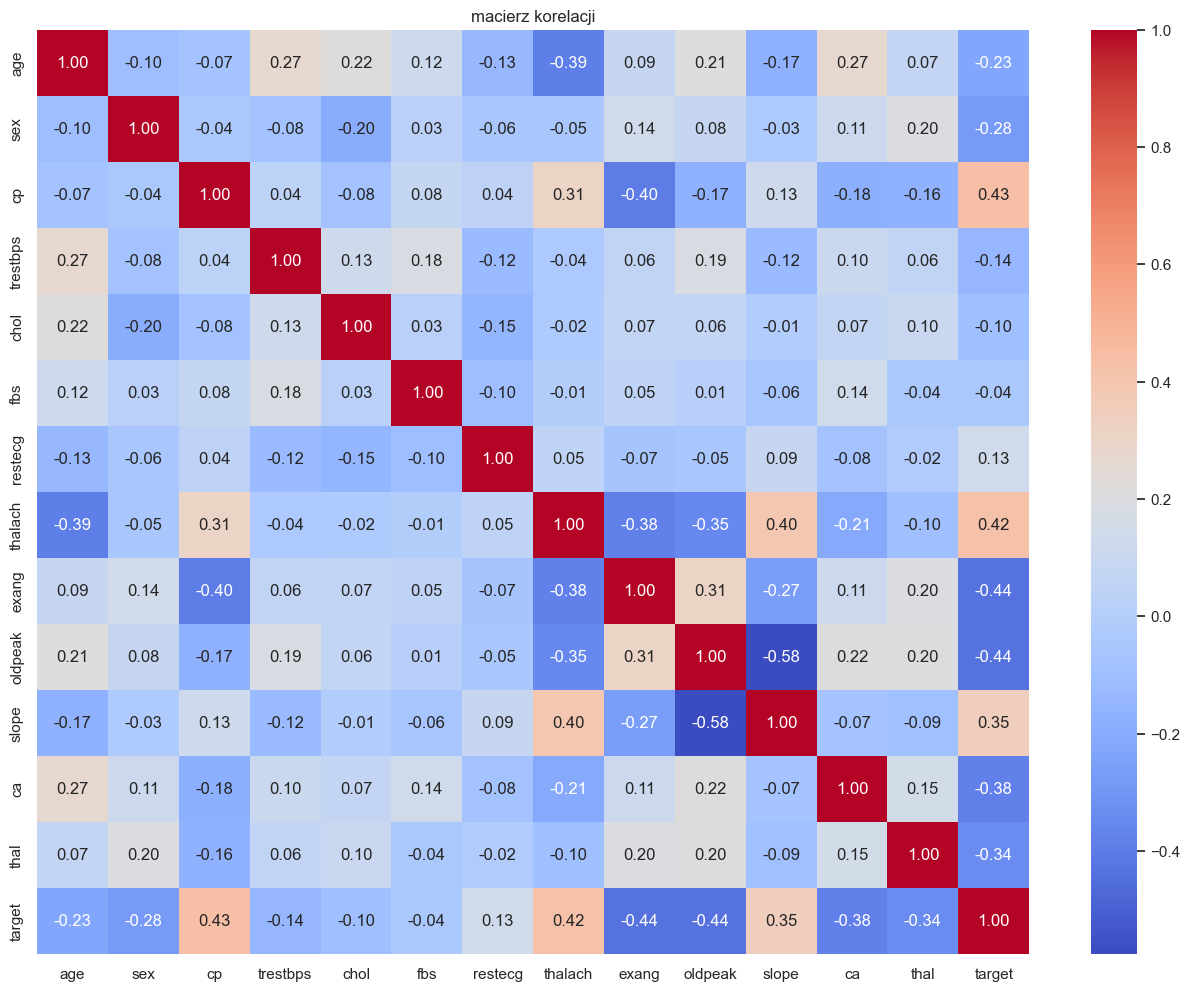

In [33]:
corr_matrix = df.corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("macierz korelacji")
plt.show()

Wyznaczono macierz korelacji r Pearson na podstawie której nie zaobserwowano silnych korelacji liniowych pomiędzy danymi.

# Macierz korelacji r Pearson > 0,4

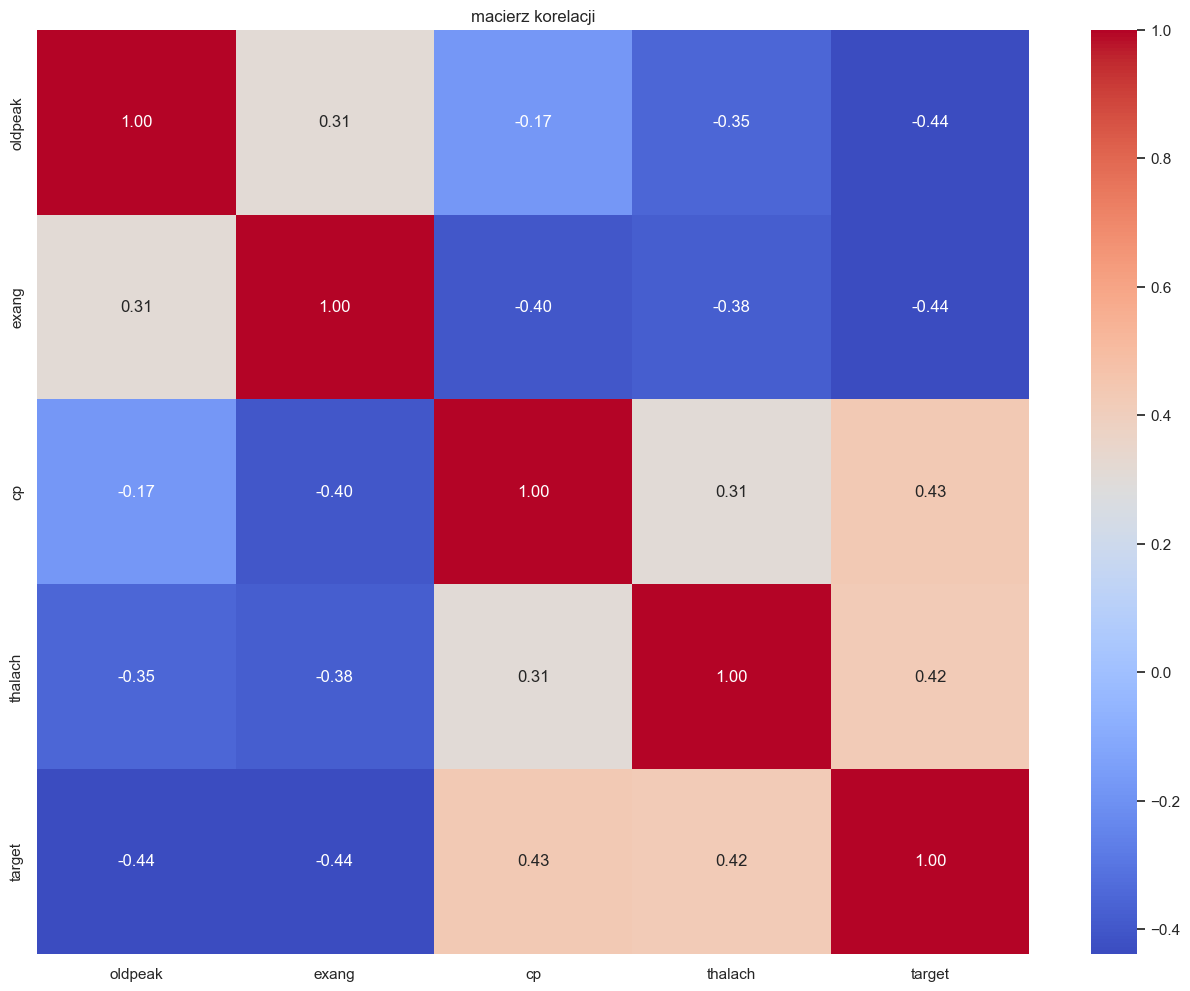

In [37]:
df2 = df[['oldpeak','exang','cp','thalach','target']]
df2.head()
corr_matrix_04 = df2.corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix_04, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("macierz korelacji")
plt.show()

Wyróżniono 4 parametry z największą korelacją r Pearson na podstawie których tworzono później model.

# Macierz korelarcji Spearmana

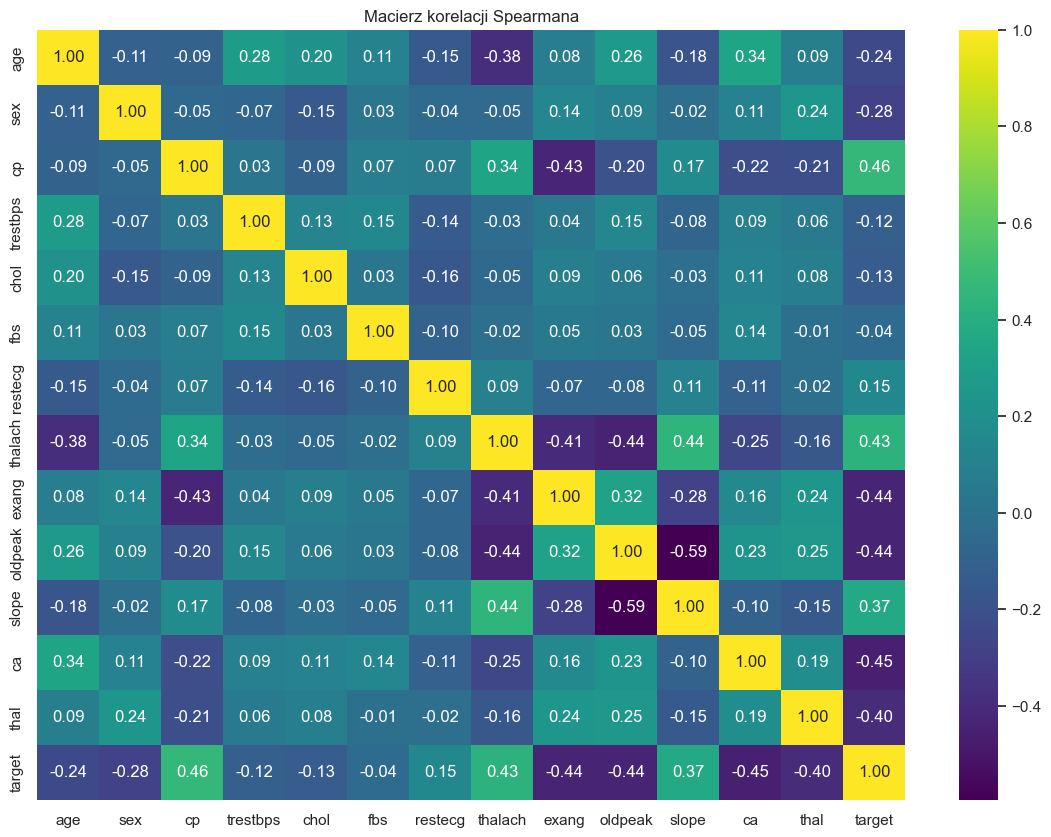

In [40]:
spearman_corr = df.corr(method='spearman')
plt.figure(figsize=(14, 10))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="viridis")
plt.title('Macierz korelacji Spearmana')
plt.show()

Stworzono macierz korelacji Spearmana w celu sprawdzenia zależności monotonicznych pomiędzy danymi, ale w tym przypadku również nie zauważono silnych korelacji.

# Współczynnik CHI^2

In [45]:
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target = 'target'

X = df[features]
y = df[target]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

chi2_scores, p_values = chi2(X_scaled, y)

chi2_df = pd.DataFrame({
    'Feature': features,
    'Chi2 Score': chi2_scores,
    'p-value': p_values
}).sort_values(by='Chi2 Score', ascending=False)

chi2_df

,Feature,Chi2 Score,p-value
8,exang,130.470927,3.232318e-30
2,cp,72.607974,1.581388e-17
11,ca,52.656480,3.972979e-13
9,oldpeak,40.911849,1.592527e-10
1,sex,24.373650,7.934661e-07
10,slope,16.836974,4.073193e-05
7,thalach,9.471895,2.086437e-03
12,thal,6.457822,1.104650e-02
6,restecg,4.869671,2.733271e-02
0,age,3.630553,5.672798e-02


Stworzono tabele z wartościami współczynnika chi^2, który opisuje jak rozkład częstości zmiennej wpływa na wartość target.

# Random Forrest - top 4 r Pearson

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       100
           1       0.97      0.99      0.98       105

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205



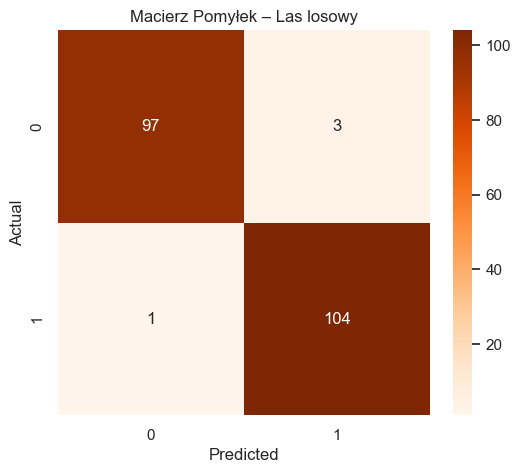

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

selected_features = ['oldpeak', 'exang', 'cp', 'thalach']
X = df[selected_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Macierz Pomyłek – Las losowy')
plt.show()

W pierwszej kolejności stowrzono model lasu losowego z wykorzystaniem czterech parametrów z największym wpływem na target według współczynnika r Pearson

# Random Forrest - top 4 CHI^2

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       100
           1       0.91      0.94      0.93       105

    accuracy                           0.92       205
   macro avg       0.92      0.92      0.92       205
weighted avg       0.92      0.92      0.92       205



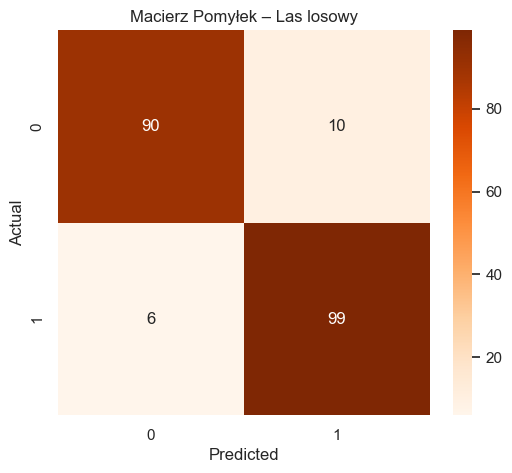

In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

selected_features_2 = ['oldpeak', 'exang', 'cp', 'ca']
X = df[selected_features_2]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Macierz Pomyłek – Las losowy')
plt.show()

Następnie stowrzono model lasu losowego z wykorzystaniem czterech parametrów z największym współczynnikiem CHI^2

# Random Forrest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



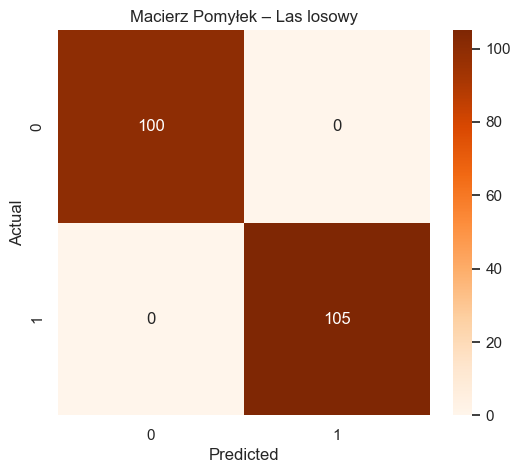

In [102]:
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Macierz Pomyłek – Las losowy')
plt.show()

Model lasu losowego z wykorzystaniem wszystkich dostępnych danych.

# Drzewo decyzyjne - max_depth = 4

=== Classification Report (Decision Tree) ===
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       100
           1       0.82      0.88      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205



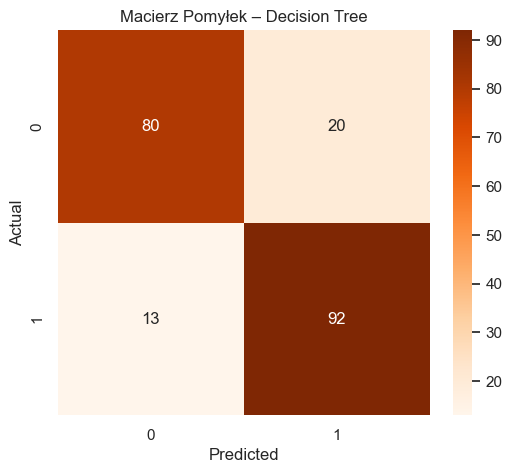

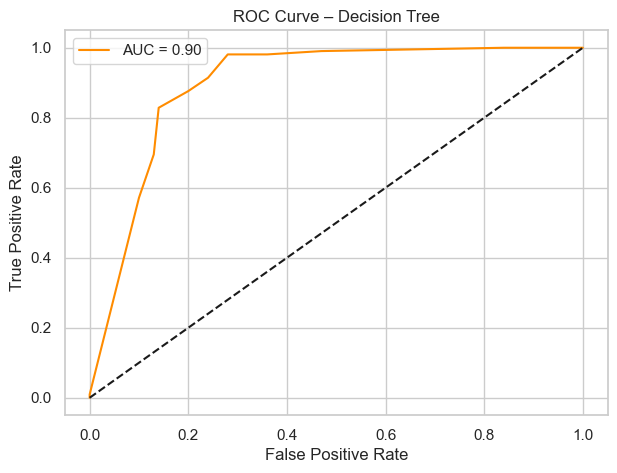

In [106]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tree_model = DecisionTreeClassifier(
    max_depth=4,             
    random_state=42,
    class_weight='balanced'   
)
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)
y_proba = tree_model.predict_proba(X_test)[:, 1]

print("=== Classification Report (Decision Tree) ===")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Macierz Pomyłek – Decision Tree')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Decision Tree')
plt.legend()
plt.grid(True)
plt.show()

Przygotowano model wykorzystujący drzewo decyzyjne o głębokości 4.

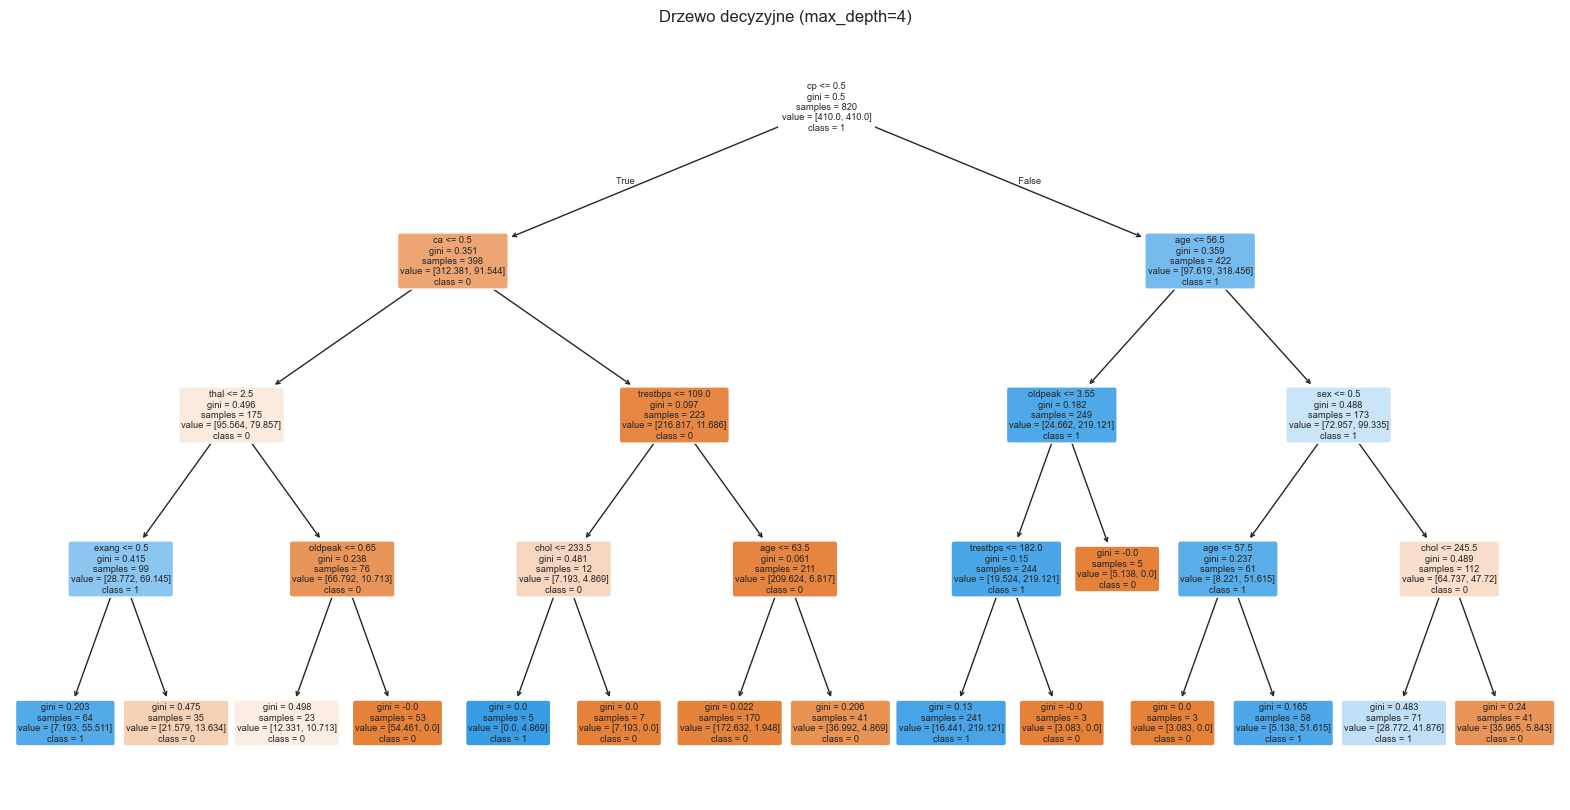

In [109]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model, 
          feature_names=features,
          class_names=['0', '1'],
          filled=True, 
          rounded=True)
plt.title("Drzewo decyzyjne (max_depth=4)")
plt.show()

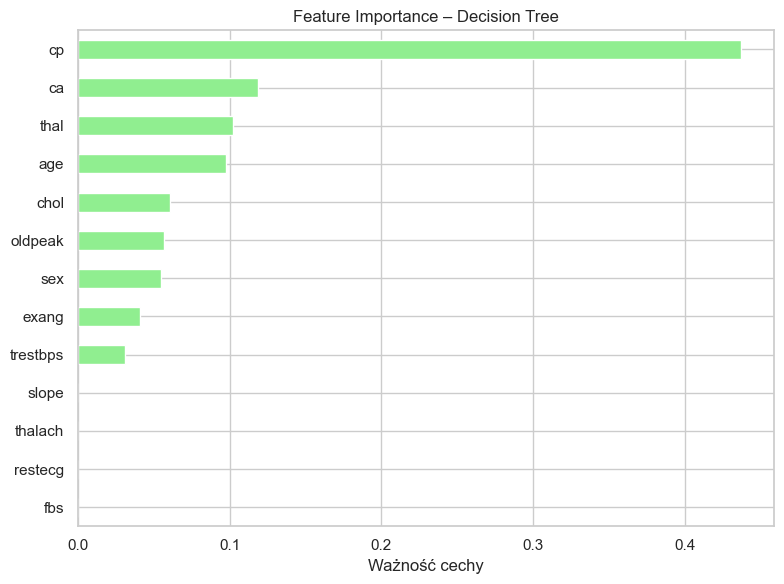

In [110]:
importances = pd.Series(tree_model.feature_importances_, index=features)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances_sorted.plot(kind='barh', color='lightgreen')
plt.title('Feature Importance – Decision Tree')
plt.xlabel('Ważność cechy')
plt.tight_layout()
plt.grid(True)
plt.show()

Histogram ważności cech według drzewa decyzyjnego o głębokości 4.

# Drzewo decyzyjne - max_depth = 9

=== Classification Report (Decision Tree) ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



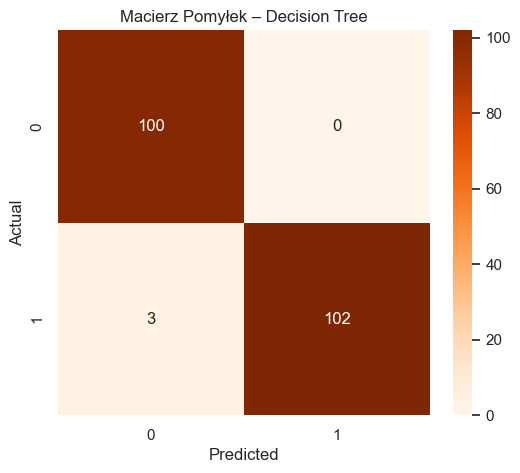

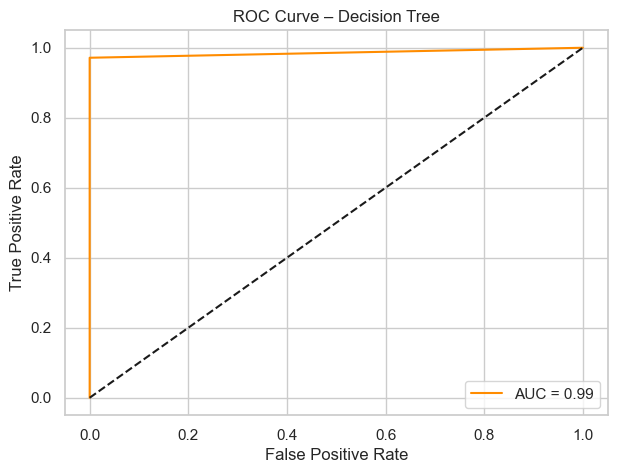

In [115]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tree_model = DecisionTreeClassifier(
    max_depth=9,
    random_state=42,
    class_weight='balanced'   
)
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)
y_proba = tree_model.predict_proba(X_test)[:, 1]

print("=== Classification Report (Decision Tree) ===")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Macierz Pomyłek – Decision Tree')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Decision Tree')
plt.legend()
plt.grid(True)
plt.show()

Stworzono model drzewa decyzyjnego z głębokością 9 i zaobserwowano, że zwiększanie głębokości nie wpływa już na otrzymywane wyniki.

# Model regresji logistycznej

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

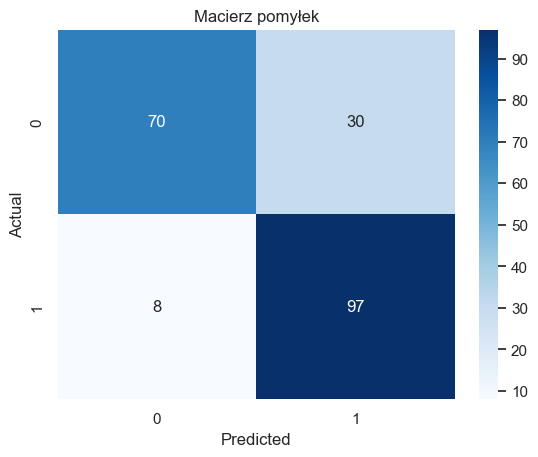

              precision    recall  f1-score   support

           0       0.90      0.70      0.79       100
           1       0.76      0.92      0.84       105

    accuracy                           0.81       205
   macro avg       0.83      0.81      0.81       205
weighted avg       0.83      0.81      0.81       205



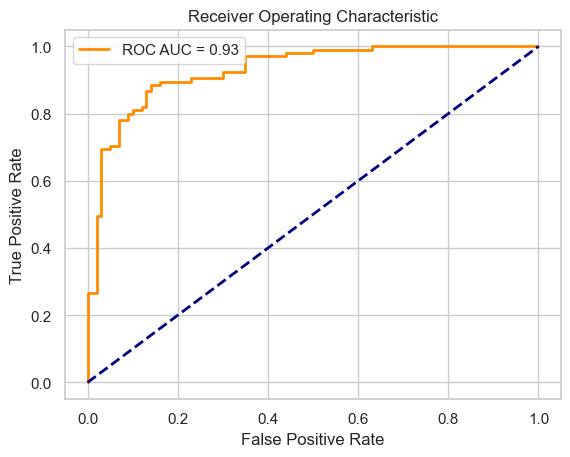

In [122]:
from sklearn.metrics import roc_curve, auc

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Macierz pomyłek')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.grid(True)
plt.show()

# Regresja logistyczna + backward step regression

In [125]:
import statsmodels.api as sm
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler

X = df[features]
y = df['target']

X_class0 = X[y == 0]
X_class1 = X[y == 1]
y_class0 = y[y == 0]
y_class1 = y[y == 1]

X0_train, X0_test, y0_train, y0_test = train_test_split(X_class0, y_class0, test_size=0.2, random_state=42)
X1_train, X1_test, y1_train, y1_test = train_test_split(X_class1, y_class1, test_size=0.2, random_state=42)

X_train = pd.concat([X0_train, X1_train])
y_train = pd.concat([y0_train, y1_train])
X_test = pd.concat([X0_test, X1_test])
y_test = pd.concat([y0_test, y1_test])

X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_named = pd.DataFrame(X_train_scaled, columns=features)
X_test_named = pd.DataFrame(X_test_scaled, columns=features)

X_train_named = pd.DataFrame(X_train_scaled, columns=features).reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

def backward_elimination(X, y, significance_level=0.05):
    X = X.copy()
    while True:
        X_with_const = sm.add_constant(X)
        model = sm.Logit(y, X_with_const).fit(disp=False)
        p_vals = model.pvalues.iloc[1:]  # bez interceptu
        max_p = p_vals.max()
        if max_p > significance_level:
            feature_to_remove = p_vals.idxmax()
            print(f"Usuwam zmienną: {feature_to_remove} (p = {max_p:.4f})")
            X = X.drop(columns=feature_to_remove)
        else:
            break
    return X, model

X_train_selected, final_model = backward_elimination(X_train_named, y_train)

print(final_model.summary())

Usuwam zmienną: age (p = 0.3993)
Usuwam zmienną: fbs (p = 0.4420)
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  819
Model:                          Logit   Df Residuals:                      807
Method:                           MLE   Df Model:                           11
Date:                Tue, 10 Jun 2025   Pseudo R-squ.:                  0.4942
Time:                        11:13:53   Log-Likelihood:                -286.98
converged:                       True   LL-Null:                       -567.42
Covariance Type:            nonrobust   LLR p-value:                3.241e-113
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1207      0.111     -1.084      0.278      -0.339       0.098
sex           -0.8665      0.131     -6.622      0.000      -1.12

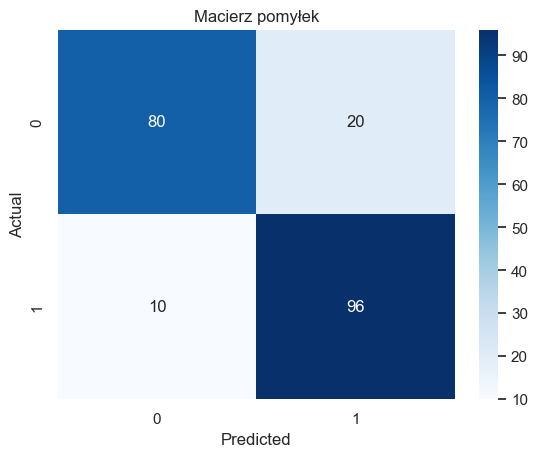

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       100
           1       0.83      0.91      0.86       106

    accuracy                           0.85       206
   macro avg       0.86      0.85      0.85       206
weighted avg       0.86      0.85      0.85       206



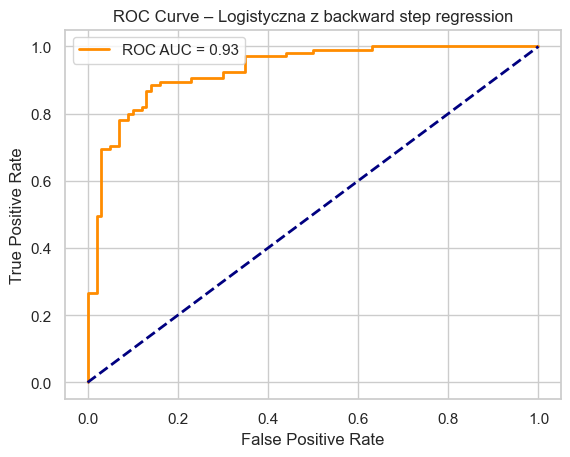

In [127]:
X_test_selected = X_test_named[X_train_selected.columns]

y_proba = final_model.predict(sm.add_constant(X_test_selected))
y_pred = (y_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Macierz pomyłek')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))


plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistyczna z backward step regression')
plt.legend()
plt.grid(True)
plt.show()

W zależności od wykorzystanej statystyki różne zmienne mają największy wpływ na zmienną objaśnianą.


# W przypadku r Pearson są to:

oldpeak

exang

cp

thalach


# CHI^2:

exang

cp

ca

oldpeak


# Feature Importance - decision tree:

cp

ca

thal 

age


# Podsumowanie modeli

In [130]:
model = {
    'Regresja logistyczna': 0.81,
    'Regresja logistyczna + backward step regression': 0.85,
    'Las losowy z 4 najważniejszymi parametrami dla r Pearson': 0.98,
    'Las losowy z 4 najważniejszymi parametrami dla CHI^2': 0.92,
    'Las losowy z wszystkimi parametrami': 1.00,
    'Drzewo decyzyjne, głębokość = 4': 0.84,
    'Drzewo decyzyjne, głębokość 9 i większa': 0.99}
podsumowanie = pd.DataFrame.from_dict(model, orient='index', columns=['Accuracy'])
podsumowanie

,Accuracy
Regresja logistyczna,0.81
Regresja logistyczna + backward step regression,0.85
Las losowy z 4 najważniejszymi parametrami dla r Pearson,0.98
Las losowy z 4 najważniejszymi parametrami dla CHI^2,0.92
Las losowy z wszystkimi parametrami,1.00
"Drzewo decyzyjne, głębokość = 4",0.84
"Drzewo decyzyjne, głębokość 9 i większa",0.99


Las losowy jest zdecydowanie najskuteczniejszym modelem w tym zadaniu, niezależnie od liczby cech – jednak model z wszystkimi cechami osiągający 100% skuteczności powinien być zweryfikowany pod kątem przeuczenia.

Selekcja cech oparta na korelacji Pearsona okazała się skuteczniejsza niż test chi-kwadrat, co może wskazywać, że w danych dominowały zależności liniowe. 

Regresja logistyczna daje stabilne, interpretowalne wyniki, ale może być niewystarczająca w bardziej złożonych zadaniach klasyfikacyjnych.

Backward stepwise regression nie przyniosła istotnych korzyści w zakresie skuteczności – może być jednak przydatna, gdy zależy nam na redukcji liczby cech i interpretowalności modelu.

Kontrola złożoności modeli drzewiastych (np. przez ograniczenie głębokości) pozwala na kompromis między dokładnością a generalizacją.

Z uwagi na stosunkowo małą bazę danych (1025 rekordów), można sobie pozwolić na bardziej skomplikowany i tym samym dokadniejszy model. Wszystkie obliczenia wykonują się wzgędnie szybko, dlatego nie trzeba specjalnie upraszczać modelu przez np. zmniejszenie ilości parametrów.